In [ ]:
# Leaf Disease Classification using Custom CNN

# Install required packages and ensure environment is ready
import subprocess
import sys

# Install required packages
packages = ['tensorflow', 'numpy', 'matplotlib', 'scikit-learn', 'seaborn', 'pillow']

print("Installing required packages...")
for package in packages:
    try:
        __import__(package)
        print(f"✓ {package} is already installed")
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        print(f"✓ {package} installed successfully")

print("\nAll required packages are ready!")

Installing required packages...
✓ tensorflow is already installed
✓ numpy is already installed
✓ matplotlib is already installed
Installing scikit-learn...
✓ scikit-learn installed successfully
✓ seaborn is already installed
Installing pillow...
✓ pillow installed successfully

All required packages are ready!


# Data loading and preprocessing
This section loads the dataset from the local folder, sets image dimensions, and prepares training/validation datasets.

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set the dataset path to the local folder
# Update this path if you move the dataset folder
dataset_path = r'C:\Users\singh\Desktop\8th_project\1'

# Define image dimensions and batch size for training
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32

# Load the dataset from the directory structure
# TensorFlow will infer labels from subfolder names
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

# Store class names and number of categories for later use
class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Class names: {class_names}")
print(f"Number of classes: {num_classes}")

Found 4000 files belonging to 8 classes.
Using 3200 files for training.
Found 4000 files belonging to 8 classes.
Using 800 files for validation.
Class names: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']
Number of classes: 8


# Preprocessing and dataset performance
This section normalizes image pixel values and optimizes the dataset pipeline for training.

In [ ]:
# Normalize pixel values to be in the [0, 1] range
normalization_layer = tf.keras.layers.Rescaling(1./255)

# Apply normalization to the training and validation datasets
normalized_train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
normalized_val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# Configure dataset for performance: cache and prefetch data
AUTOTUNE = tf.data.AUTOTUNE

train_ds_optimized = normalized_train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds_optimized = normalized_val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Dataset preprocessing complete. Ready for model building.")

Dataset preprocessing complete. Ready for model building.


# Model definition
Create the custom convolutional neural network and compile it for training.

In [ ]:
# Define and compile the Custom CNN Model
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

# Compile the model with Adam optimizer and sparse categorical crossentropy loss
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

model.summary()
print("Custom CNN model defined and compiled successfully.")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,518,088 (24.86 MB)

 Trainable params: 6,518,088 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

Custom CNN model defined and compiled successfully.


# Model training
Train the custom CNN model and monitor validation performance.

In [ ]:
# Train the model for 30 epochs
EPOCHS = 30

history = model.fit(
    train_ds_optimized,
    epochs=EPOCHS,
    validation_data=val_ds_optimized
)

print("Model training complete.")

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.3356 - loss: 1.6838 - val_accuracy: 0.5587 - val_loss: 1.2063
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.6416 - loss: 0.9467 - val_accuracy: 0.8087 - val_loss: 0.5624
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.7981 - loss: 0.5744 - val_accuracy: 0.8350 - val_loss: 0.4499
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.8678 - loss: 0.3948 - val_accuracy: 0.8750 - val_loss: 0.3541
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.8884 - loss: 0.3422 - val_accuracy: 0.9112 - val_loss: 0.2475
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.9200 - loss: 0.2198 - val_accuracy: 0.9350 - val_loss: 0.2072
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 62886s 635s/step - accuracy: 0.9153 - loss: 0.2481 - val_accuracy: 0.9300 - val_loss: 0.2112
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.9522 - loss: 0.1572 - val

# Evaluation and metrics
Evaluate the trained model on the validation set and display performance metrics.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Classification Report:
                  precision

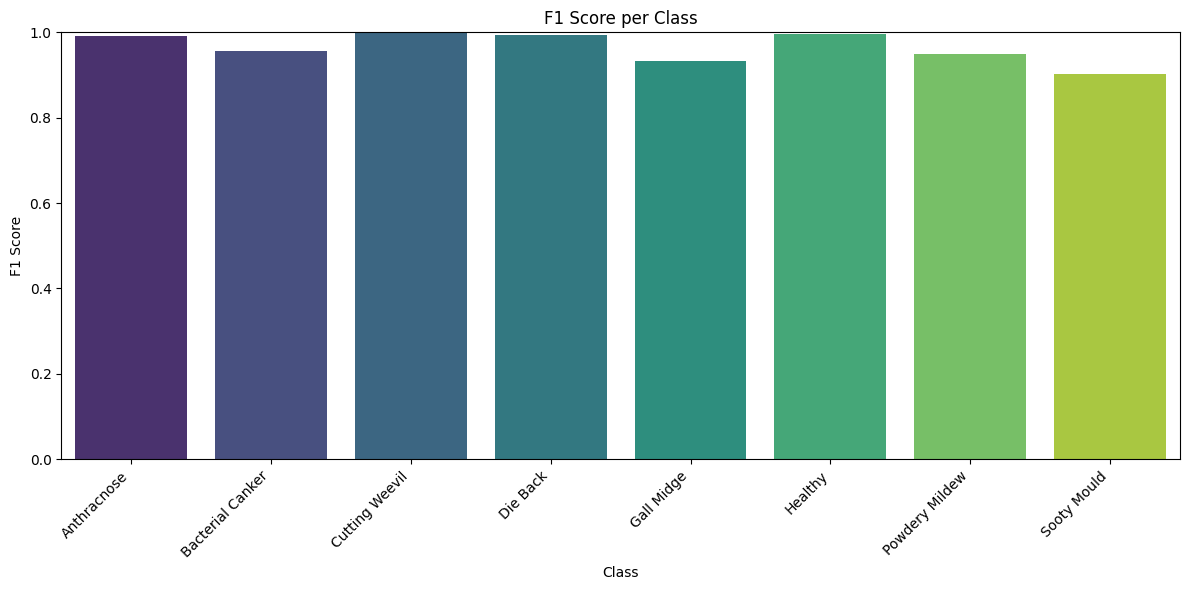

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Get true labels and predictions for the validation set
# This loops through the validation dataset and records true vs predicted classes.
y_true = []
y_pred = []

for images, labels in val_ds_optimized:
    y_true.extend(labels.numpy())
    predictions = model.predict(images)
    y_pred.extend(tf.argmax(predictions, axis=1).numpy())

# Convert lists to numpy arrays for metric computation
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Generate classification report
target_names = class_names
report = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=target_names))

# Extract F1 scores for plotting
f1_scores = [report[name]['f1-score'] for name in target_names]

# Plot F1 Score Chart
plt.figure(figsize=(12, 6))
sns.barplot(x=target_names, y=f1_scores, palette='viridis')
plt.title('F1 Score per Class')
plt.xlabel('Class')
plt.ylabel('F1 Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Confusion matrix analysis
Visualize class-by-class performance to identify which diseases are most confused.

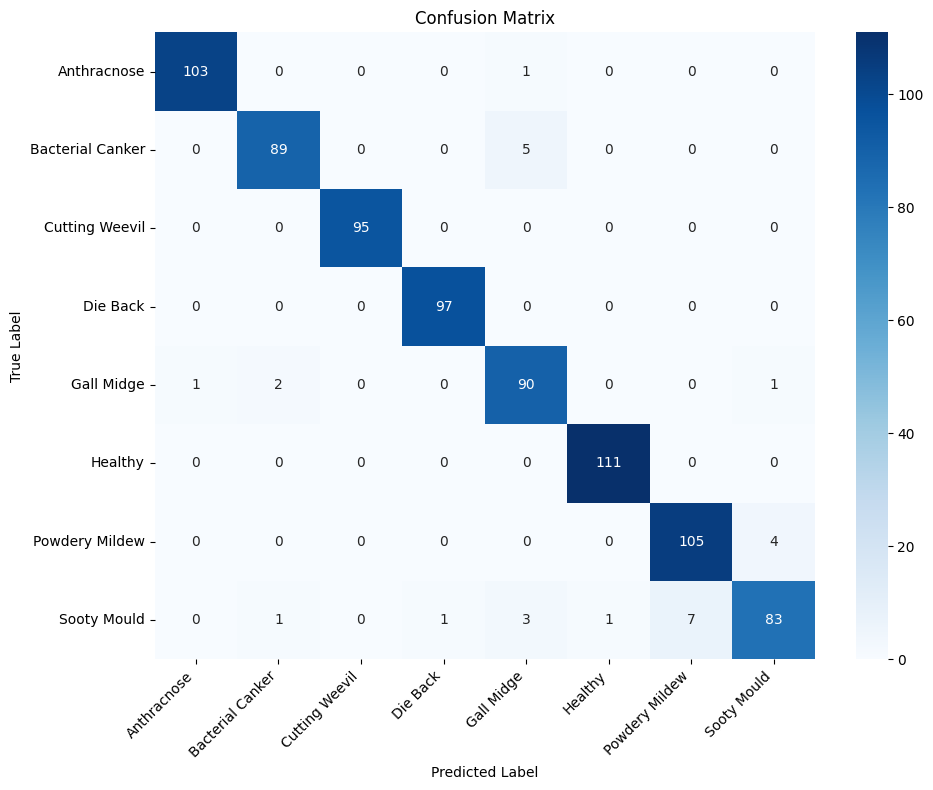

In [ ]:
# Generate Confusion Matrix
# This matrix shows how often each class was predicted correctly or incorrectly.
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Training history plots
Plot accuracy and loss trends to check overfitting or underfitting.

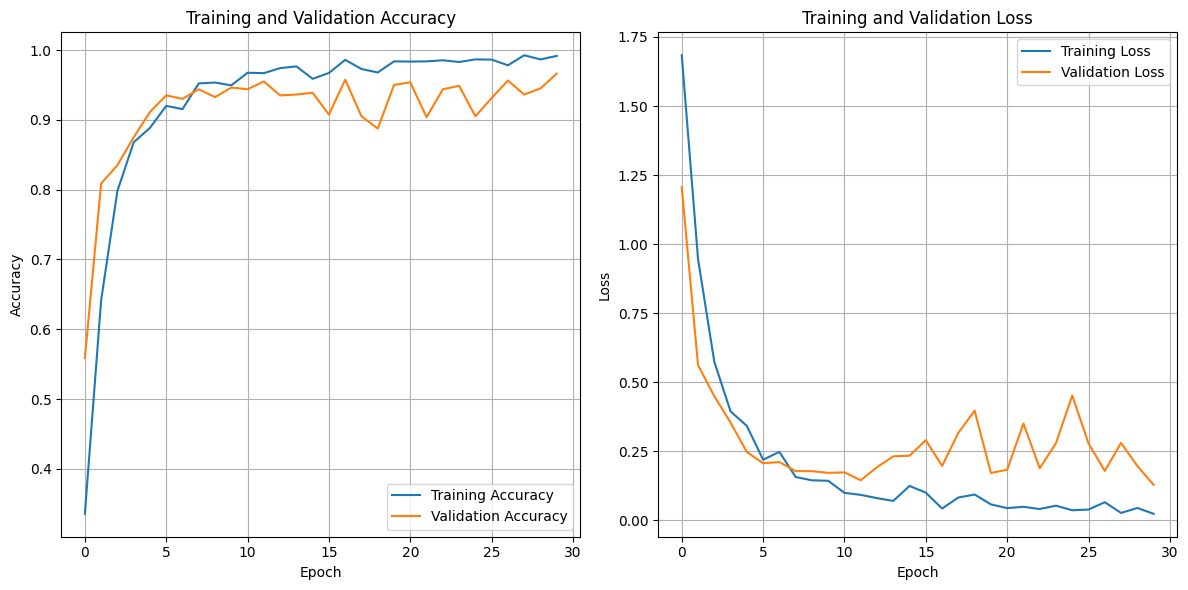

Accuracy and Loss curves plotted successfully.


In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy curves to compare how the model learns
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot training and validation loss curves to monitor convergence
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
print("Accuracy and Loss curves plotted successfully.")

# Sample predictions
Show a few validation images alongside their predicted and true labels.

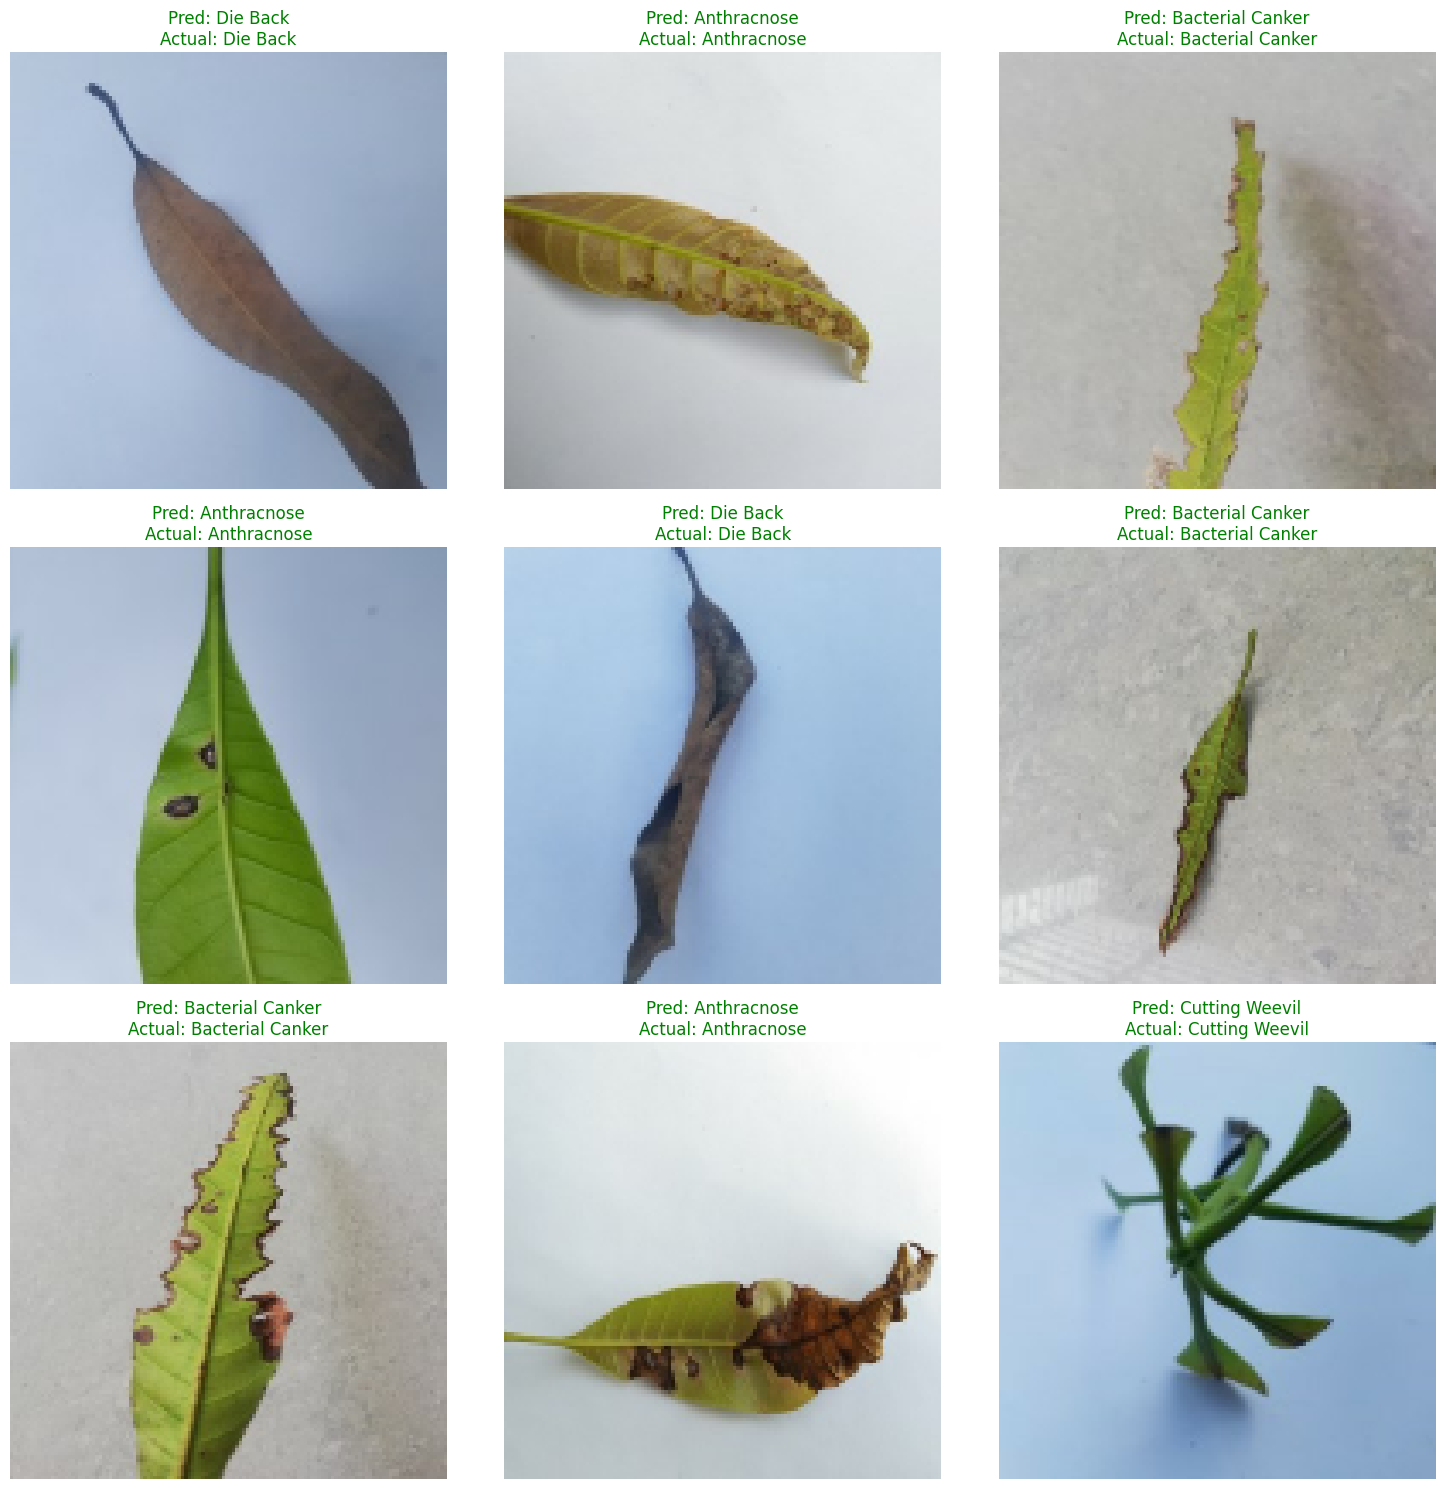

In [ ]:
import matplotlib.pyplot as plt

# Display a small set of validation images with predicted and actual labels
plt.figure(figsize=(15, 15))
for i, (images, labels) in enumerate(val_ds_optimized.take(9)):
    for j in range(len(images)):
        if i * BATCH_SIZE + j >= 9:  # Display 9 images
            break

        ax = plt.subplot(3, 3, i * BATCH_SIZE + j + 1)
        img = images[j]
        true_label = class_names[labels[j].numpy()]

        # Expand dimensions to create a batch for prediction
        img_array = tf.expand_dims(img, 0)
        predictions = model.predict(img_array, verbose=0)  # Suppress progress output
        predicted_label = class_names[tf.argmax(predictions[0]).numpy()]

        plt.imshow(img.numpy())
        plt.title(f"Pred: {predicted_label}\nActual: {true_label}", color=('green' if predicted_label == true_label else 'red'))
        plt.axis("off")
    if i * BATCH_SIZE + j >= 9:
        break
plt.tight_layout()
plt.show()